## Preprocessing pipeline

This notebook prepares **two model-ready datasets** for neighborhood-level crime prediction:

- **`base_dataset`**: cleaned **non-spatial** dataset (tabular predictors + targets)
- **`spatial_dataset`**: cleaned dataset with **spillover features based on exogenous predictors only** (Queen contiguity)

Key constraint: **no contemporaneous target-based spatial lag is included in exported model-ready datasets**.


## 1. Imports and configuration


In [1]:
from __future__ import annotations

import logging
import re
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Optional

import numpy as np
import pandas as pd
import geopandas as gpd
import pyogrio
import matplotlib.pyplot as plt

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger(__name__)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

@dataclass(frozen=True)
class Config:
    # Paths
    tabular_csv: Path = Path("datasets/cleaned_crime_nbh_2024.csv")

    # This GeoPackage is already tabular+geometry merged in `1 - Merging Datasets.ipynb`
    spatial_gpkg: Path = Path("datasets/merged_crime_nbh_2024.gpkg")
    spatial_layer: Optional[str] = None  # if None: pick first layer

    # If True, we will *not* merge geometry again in this notebook.
    # Instead, section 5 performs a key consistency audit and uses the merged GPKG as-is.
    use_merged_gpkg_as_primary: bool = True

    # Merge keys
    tabular_key: str = "gwb_code_10"
    spatial_key: str = "gwb_code_10"

    # Raw columns
    raw_crime_col: str = "GeregistreerdeMisdrijven_1"
    raw_population_col: str = "a_inw"

    # Metric CRS for NL (already used in gpkg, but we enforce if needed)
    metric_crs: str = "EPSG:28992"

    # Cleaning / filtering
    missing_col_threshold: float = 0.20

    # Exogenous spillover candidates (3-5 chosen from these if available)
    # CHANGE THESE TO FEATURES BASED ON LITERATURE. The 'Queen Lag' features are created using these.
    spillover_candidates: tuple[str, ...] = (
        "pop_density_per_km2",  # derived if a_inw & a_opp_ha exist
        "ste_oad",              # address density (urbanization proxy)
        "p_ink_li",             # low-income share (poverty proxy)
        "p_huurw",              # renter share
        "g_pau_km",             # poverty / deprivation proxy
        "g_pau_hh",
        "p_hh_lkk",
        "p_hh_osm",
        "pst_mvp",
        "pst_dekp",
    )

    # Exports
    # Keep names aligned with the modeling MVP notebook.
    export_base_csv: Path = Path("datasets/model_ready_crime_nbh_2024.csv")
    export_spatial_csv: Path = Path("datasets/spatial_dataset_crime_nbh_2024.csv")
    export_spatial_gpkg: Path = Path("datasets/spatial_dataset_crime_nbh_2024.gpkg")

CFG = Config()
print(CFG)


Config(tabular_csv=PosixPath('datasets/cleaned_crime_nbh_2024.csv'), spatial_gpkg=PosixPath('datasets/merged_crime_nbh_2024.gpkg'), spatial_layer=None, use_merged_gpkg_as_primary=True, tabular_key='gwb_code_10', spatial_key='gwb_code_10', raw_crime_col='GeregistreerdeMisdrijven_1', raw_population_col='a_inw', metric_crs='EPSG:28992', missing_col_threshold=0.2, spillover_candidates=('pop_density_per_km2', 'ste_oad', 'p_ink_li', 'p_huurw', 'g_pau_km', 'g_pau_hh', 'p_hh_lkk', 'p_hh_osm', 'pst_mvp', 'pst_dekp'), export_base_csv=PosixPath('datasets/model_ready_crime_nbh_2024.csv'), export_spatial_csv=PosixPath('datasets/spatial_dataset_crime_nbh_2024.csv'), export_spatial_gpkg=PosixPath('datasets/spatial_dataset_crime_nbh_2024.gpkg'))


## Helper functions

Functions below keep the pipeline reproducible and defensible. Most cells below call these helpers and print compact audit outputs.


In [2]:
PLACEHOLDER_TOKENS = {".", "", " ", "  "}


def list_gpkg_layers(path: Path):
    layers = pyogrio.list_layers(path)
    return [row[0] for row in layers]


def load_tabular(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(path)
    df = pd.read_csv(path)
    logger.info("Loaded tabular: %s rows, %s cols", len(df), df.shape[1])
    return df


def load_spatial(path: Path, layer: Optional[str] = None) -> gpd.GeoDataFrame:
    if not path.exists():
        raise FileNotFoundError(path)
    layer_names = list_gpkg_layers(path)
    print("Available GeoPackage layers:", layer_names)
    if layer is None:
        layer = layer_names[0]
    if layer not in layer_names:
        raise ValueError(f"Layer '{layer}' not found. Available: {layer_names}")

    gdf = gpd.read_file(path, layer=layer, engine="pyogrio")
    logger.info("Loaded spatial layer '%s': %s rows, %s cols", layer, len(gdf), gdf.shape[1])
    print("CRS:", gdf.crs)
    print("Columns:", list(gdf.columns))
    return gdf


def standardize_key(s: pd.Series) -> pd.Series:
    return s.astype("string").fillna(pd.NA).str.strip().str.upper()


def audit_duplicates(df: pd.DataFrame, key: str, label: str) -> pd.DataFrame:
    dup = df[key].duplicated(keep=False)
    n_dup = int(dup.sum())
    logger.info("%s duplicate keys in %s: %s", key, label, n_dup)
    if n_dup == 0:
        return pd.DataFrame(columns=[key, "count"])
    out = df.loc[dup, [key]].value_counts().reset_index(name="count")
    return out


def merge_tabular_spatial(df_tab: pd.DataFrame, gdf_spatial: gpd.GeoDataFrame, tab_key: str, spatial_key: str):
    df_tab = df_tab.copy()
    gdf_spatial = gdf_spatial.copy()

    df_tab[tab_key] = standardize_key(df_tab[tab_key])
    gdf_spatial[spatial_key] = standardize_key(gdf_spatial[spatial_key])

    dup_tab = audit_duplicates(df_tab, tab_key, "tabular")
    dup_spa = audit_duplicates(gdf_spatial, spatial_key, "spatial")

    gdf = df_tab.merge(
        gdf_spatial[[spatial_key, "geometry"]],
        how="left",
        left_on=tab_key,
        right_on=spatial_key,
        validate="m:1",
    )
    gdf = gpd.GeoDataFrame(gdf, geometry="geometry", crs=gdf_spatial.crs)

    n_total = len(df_tab)
    n_matched = int(gdf["geometry"].notna().sum())
    n_unmatched = n_total - n_matched
    pct = 100.0 * n_matched / n_total if n_total else 0.0

    unmatched_keys = (
        gdf.loc[gdf["geometry"].isna(), tab_key]
        .dropna()
        .astype("string")
        .unique()
        .tolist()
    )

    audit = {
        "rows_tabular": n_total,
        "rows_matched_geometry": n_matched,
        "rows_unmatched": n_unmatched,
        "pct_matched": pct,
        "dup_keys_tabular": int(df_tab[tab_key].duplicated().sum()),
        "dup_keys_spatial": int(gdf_spatial[spatial_key].duplicated().sum()),
        "rows_missing_geometry": int(gdf["geometry"].isna().sum()),
    }
    audit_df = pd.DataFrame([audit])

    print("\n=== Merge audit summary ===")
    print(audit_df.to_string(index=False))
    if unmatched_keys:
        print("\nSample unmatched keys (up to 15):", unmatched_keys[:15])
    else:
        print("\nAll keys matched.")

    if len(dup_tab) > 0:
        print("\nDuplicate keys in tabular (top 10):")
        print(dup_tab.head(10).to_string(index=False))
    if len(dup_spa) > 0:
        print("\nDuplicate keys in spatial (top 10):")
        print(dup_spa.head(10).to_string(index=False))

    return gdf, audit_df


def clean_placeholders_and_coerce_numeric(df: pd.DataFrame, id_cols: Iterable[str]):
    df = df.copy()
    id_cols = [c for c in id_cols if c in df.columns]

    before_dtypes = df.dtypes.astype(str)

    obj_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
    for c in obj_cols:
        s = df[c].astype("string")
        s = s.str.replace(r"\s+", " ", regex=True)
        s = s.replace(list(PLACEHOLDER_TOKENS), pd.NA)
        df[c] = s

    for c in obj_cols:
        if c in id_cols:
            continue
        s = df[c]
        mask = s.str.match(r"^-?\d{1,3}(?:\.\d{3})*,\d+$", na=False) | s.str.match(r"^-?\d+,\d+$", na=False)
        if mask.any():
            df.loc[mask, c] = s.loc[mask].str.replace(".", "", regex=False).str.replace(",", ".", regex=False)

    after_dtypes = df.dtypes.astype(str).copy()
    for c in df.columns:
        if c in id_cols:
            continue
        if df[c].dtype.name in ("string", "object"):
            df[c] = pd.to_numeric(df[c], errors="ignore")
        after_dtypes[c] = str(df[c].dtype)

    miss_pct = df.isna().mean().mul(100).round(2)
    summary = pd.DataFrame({
        "column": df.columns,
        "dtype_before": before_dtypes.reindex(df.columns).values,
        "dtype_after": after_dtypes.reindex(df.columns).values,
        "pct_missing": miss_pct.values,
    }).sort_values("pct_missing", ascending=False)

    return df, summary


def create_targets(df: pd.DataFrame, crime_col: str, pop_col: str):
    """Create the single modeling target.

    Thesis requirement: create **one** target variable only: `log_crime_count = log1p(crime_count)`.

    We keep `crime_count` and `population` as raw/context columns (not used as targets), and we keep
    `population_zero` only as a flag for data quality checks.
    """
    df = df.copy()
    df["crime_count"] = pd.to_numeric(df[crime_col], errors="coerce").astype(float)
    df["population"] = pd.to_numeric(df[pop_col], errors="coerce").astype(float)

    df["population_zero"] = df["population"].fillna(0) <= 0

    # Single target used downstream
    df["log_crime_count"] = np.log1p(np.clip(df["crime_count"], 0, None))

    return df


def plot_target_histograms(df: pd.DataFrame):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].hist(df["crime_count"].clip(lower=0).dropna(), bins=40, color="steelblue", edgecolor="white")
    axes[0].set_title("crime_count")

    axes[1].hist(df["log_crime_count"].dropna(), bins=40, color="steelblue", edgecolor="white")
    axes[1].set_title("log_crime_count = log1p(count)")

    plt.tight_layout()
    plt.show()


def drop_high_missing_columns(df: pd.DataFrame, threshold: float, protect_cols: Iterable[str]):
    protect_cols = [c for c in protect_cols if c in df.columns]
    miss = df.isna().mean()
    drop_cols = [c for c in df.columns if (miss[c] > threshold and c not in protect_cols)]
    return df.drop(columns=drop_cols), drop_cols


def median_impute_numeric(df: pd.DataFrame, exclude_cols: Iterable[str]):
    df = df.copy()
    exclude_cols = [c for c in exclude_cols if c in df.columns]

    num_cols = df.select_dtypes(include=["number"]).columns.tolist()
    impute_cols = [c for c in num_cols if c not in exclude_cols]

    # Important: some numeric columns can be pandas nullable integers (Int64).
    # Median imputation can produce non-integer values, so we impute into float columns.
    df[impute_cols] = df[impute_cols].astype(float)

    medians = df[impute_cols].median(numeric_only=True)
    df[impute_cols] = df[impute_cols].fillna(medians)
    return df, medians


def ensure_metric_crs(gdf: gpd.GeoDataFrame, metric_crs: str):
    if gdf.crs is None:
        raise ValueError("Spatial data has no CRS; cannot reproject safely")
    if str(gdf.crs).upper() != metric_crs.upper():
        logger.info("Reprojecting from %s to %s", gdf.crs, metric_crs)
        gdf = gdf.to_crs(metric_crs)
    return gdf


def compute_centroid_metric(gdf: gpd.GeoDataFrame):
    """Compute centroid coordinates in metric CRS.

    We store centroids as numeric columns (x/y) instead of a second geometry column,
    because GeoPackage export supports only one active geometry column.
    """
    gdf = gdf.copy()
    cent = gdf.geometry.centroid
    gdf["centroid_x"] = cent.x
    gdf["centroid_y"] = cent.y
    return gdf


def build_queen_neighbors(gdf: gpd.GeoDataFrame, key: str):
    if key not in gdf.columns:
        raise KeyError(key)
    if gdf.geometry.isna().any():
        raise ValueError("Missing geometries present; cannot build weights")

    left = gdf[[key, "geometry"]].rename(columns={key: "k"})
    right = gdf[[key, "geometry"]].rename(columns={key: "n"})

    joined = gpd.sjoin(left, right, how="left", predicate="touches")
    joined = joined[joined["k"] != joined["n"]]

    neigh = joined.groupby("k")["n"].apply(list)
    neigh = neigh.reindex(gdf[key]).apply(lambda x: x if isinstance(x, list) else [])

    degrees = neigh.apply(len)
    summary = pd.DataFrame({
        "n_units": [len(gdf)],
        "avg_neighbors": [degrees.mean()],
        "min_neighbors": [degrees.min()],
        "max_neighbors": [degrees.max()],
        "pct_islands": [100.0 * (degrees.eq(0).mean())],
    })
    return neigh, summary


def add_spillover_lags(df: pd.DataFrame, key: str, neighbors: pd.Series, features: list[str], prefix: str = "queen", islands_fill=np.nan):
    df = df.copy().set_index(key, drop=False)

    for feat in features:
        vals = pd.to_numeric(df[feat], errors="coerce")
        lag_sum = []
        lag_mean = []
        for k, neigh_list in neighbors.items():
            if not neigh_list:
                lag_sum.append(islands_fill)
                lag_mean.append(islands_fill)
                continue
            neigh_vals = vals.reindex(neigh_list)
            lag_sum.append(neigh_vals.sum(skipna=True))
            lag_mean.append(neigh_vals.mean(skipna=True))
        df[f"{prefix}_lag_sum_{feat}"] = lag_sum
        df[f"{prefix}_lag_mean_{feat}"] = lag_mean

    return df.reset_index(drop=True)


def compact_describe(series: pd.Series):
    s = series.dropna()
    return pd.Series({
        "n": len(s),
        "mean": s.mean(),
        "std": s.std(),
        "min": s.min(),
        "p50": s.median(),
        "p95": s.quantile(0.95),
        "max": s.max(),
        "skew": s.skew(),
    })


## 2. Load raw tabular dataset


In [3]:
df_raw = load_tabular(CFG.tabular_csv)
print(df_raw.head(3))
print("\nColumns:", df_raw.columns.tolist())


INFO: Loaded tabular: 14494 rows, 124 cols


  gwb_code_10             regio    gm_naam  ind_wbi  a_inw  a_man  a_vrouw  a_00_14  a_15_24  a_25_44  a_45_64  a_65_oo  a_ongeh  a_gehuwd  a_gesch  a_verwed  \
0  BU00140000  Binnenstad-Noord  Groningen        1   4745   2470     2270       55     2365     1540      455      330     4190       330      180        40   
1  BU00140001   Binnenstad-Zuid  Groningen        1   6975   3640     3340      110     3515     2220      625      515     6140       490      275        70   
2  BU00140002   Binnenstad-Oost  Groningen        1   4400   2275     2125      120     1815     1620      455      385     3795       365      190        55   

   a_nl_all  a_eur_al  a_neu_al  a_geb_nl  a_geb_eu  a_geb_ne  a_gbl_eu  a_gbl_ne  a_geb  p_geb  a_ste  p_ste  a_hh  a_1p_hh  a_hh_z_k  a_hh_m_k  g_hhgro  \
0      3180       845       720      3180       150       230       695       490     10    3.0     15    4.0  3910     3255       565        85      1.2   
1      4350      1430      1200      4355

## 3. Load GeoPackage and inspect spatial layer


In [4]:
gdf_spatial_raw = load_spatial(CFG.spatial_gpkg, layer=CFG.spatial_layer)

print("\nRow count:", len(gdf_spatial_raw))
print("CRS:", gdf_spatial_raw.crs)
print("Geometry type counts:\n", gdf_spatial_raw.geometry.geom_type.value_counts().to_string())


Available GeoPackage layers: ['merged_crime_nbh_2024']


INFO: Loaded spatial layer 'merged_crime_nbh_2024': 14494 rows, 134 cols


CRS: EPSG:28992
Columns: ['gwb_code_10', 'gwb_code_8', 'regio', 'gm_naam', 'recs', 'gwb_code', 'ind_wbi', 'a_inw', 'a_man', 'a_vrouw', 'a_00_14', 'a_15_24', 'a_25_44', 'a_45_64', 'a_65_oo', 'a_ongeh', 'a_gehuwd', 'a_gesch', 'a_verwed', 'a_nl_all', 'a_eur_al', 'a_neu_al', 'a_geb_nl', 'a_geb_eu', 'a_geb_ne', 'a_gbl_eu', 'a_gbl_ne', 'a_geb', 'p_geb', 'a_ste', 'p_ste', 'a_hh', 'a_1p_hh', 'a_hh_z_k', 'a_hh_m_k', 'g_hhgro', 'bev_dich', 'a_woning', 'a_nb_won ', 'a_vastg', 'a_nb_vastg', 'g_wozbag', 'p_1gezw', 'p_1gezw_tw', 'p_1gezw_hw', 'p_1gezw_2w', 'p_1gezw_hvw', 'p_mgezw', 'p_leegsw', 'p_koopw', 'p_huurw', 'p_wcorpw', 'p_ov_hw', 'p_bj_me10', 'p_bj_mi10', 'g_ele', 'g_ele_tr', 'g_gas', 'p_stadsv', 'p_won_z_ag', 'p_won_m_ag ', 'p_won_zs', 'p_won_ev ', 'a_lp_pub', 'a_ons_po', 'a_ons_vovavo', 'a_ons_mbo', 'a_ons_hbo', 'a_ons_wo', 'a_opl_bvm', 'a_opl_hvm', 'a_opl_hw', 'a_arb_wz', 'p_arb_pp', 'p_arb_wn', 'p_arb_wnv', 'p_arb_wnf', 'p_arb_zs', 'a_inkont', 'g_ink_po', 'g_ink_pi', 'p_ink_li', 'p_ink_h

## 4. Standardize and verify merge keys


In [5]:
df_tab = df_raw.copy()
gdf_spatial = gdf_spatial_raw.copy()

df_tab[CFG.tabular_key] = standardize_key(df_tab[CFG.tabular_key])
gdf_spatial[CFG.spatial_key] = standardize_key(gdf_spatial[CFG.spatial_key])

print("Tabular key sample:", df_tab[CFG.tabular_key].dropna().unique()[:5])
print("Spatial key sample:", gdf_spatial[CFG.spatial_key].dropna().unique()[:5])

print("\nDuplicates (tabular):", int(df_tab[CFG.tabular_key].duplicated().sum()))
print("Duplicates (spatial):", int(gdf_spatial[CFG.spatial_key].duplicated().sum()))


Tabular key sample: <StringArray>
['BU00140000', 'BU00140001', 'BU00140002', 'BU00140003', 'BU00140004']
Length: 5, dtype: string
Spatial key sample: <StringArray>
['BU00140000', 'BU00140001', 'BU00140002', 'BU00140003', 'BU00140004']
Length: 5, dtype: string

Duplicates (tabular): 0
Duplicates (spatial): 0


## 5. Merge tabular and spatial data


In [6]:
# NOTE: Geometry was already merged in `1 - Merging Datasets.ipynb` into `CFG.spatial_gpkg`.
# By default we reuse that merged GeoPackage and only run a consistency audit here.

if CFG.use_merged_gpkg_as_primary and all(c in gdf_spatial.columns for c in [CFG.raw_crime_col, CFG.raw_population_col]):
    gdf_merged = gdf_spatial.copy()

    # Consistency audit vs tabular CSV (do NOT merge again)
    tab_k = df_tab[CFG.tabular_key]
    spa_k = gdf_merged[CFG.spatial_key]

    spa_key_set = set(spa_k.dropna().astype("string"))
    matched = tab_k.isin(spa_key_set)

    n_total = len(df_tab)
    n_matched = int(matched.sum())
    n_unmatched = int((~matched).sum())
    pct = 100.0 * n_matched / n_total if n_total else 0.0

    unmatched_keys = tab_k.loc[~matched].dropna().astype("string").unique().tolist()

    merge_audit = pd.DataFrame([
        {
            "rows_tabular": n_total,
            "rows_matched_geometry": int(gdf_merged["geometry"].notna().sum()),
            "rows_unmatched": n_unmatched,
            "pct_tabular_keys_present_in_gpkg": pct,
            "dup_keys_tabular": int(df_tab[CFG.tabular_key].duplicated().sum()),
            "dup_keys_spatial": int(gdf_merged[CFG.spatial_key].duplicated().sum()),
            "rows_missing_geometry": int(gdf_merged["geometry"].isna().sum()),
        }
    ])

    print("\n=== Key consistency audit (tabular CSV vs merged GPKG) ===")
    print(merge_audit.to_string(index=False))
    if unmatched_keys:
        print("\nSample tabular keys missing from GPKG (up to 15):", unmatched_keys[:15])
    else:
        print("\nAll tabular keys found in merged GPKG.")
else:
    # Fallback (only if you ever switch to a pure-geometry GPKG)
    gdf_merged, merge_audit = merge_tabular_spatial(
        df_tab=df_tab,
        gdf_spatial=gdf_spatial,
        tab_key=CFG.tabular_key,
        spatial_key=CFG.spatial_key,
    )

gdf_merged = ensure_metric_crs(gdf_merged, CFG.metric_crs)
gdf_merged = compute_centroid_metric(gdf_merged)

print("\nWorking GeoDataFrame:", gdf_merged.shape)
print("CRS:", gdf_merged.crs)



=== Key consistency audit (tabular CSV vs merged GPKG) ===
 rows_tabular  rows_matched_geometry  rows_unmatched  pct_tabular_keys_present_in_gpkg  dup_keys_tabular  dup_keys_spatial  rows_missing_geometry
        14494                  14494               0                             100.0                 0                 0                      0

All tabular keys found in merged GPKG.

Working GeoDataFrame: (14494, 136)
CRS: EPSG:28992


## 6. Clean numeric columns and placeholders


In [7]:
IDENTIFIER_COLS = [CFG.tabular_key, "regio", "gm_naam"]
SPATIAL_META_COLS = ["geometry", "centroid_x", "centroid_y"]

cleaned, missingness_summary = clean_placeholders_and_coerce_numeric(
    gdf_merged,
    # treat geometry as protected; centroid_x/y are numeric and will be handled as numerics
    id_cols=IDENTIFIER_COLS + ["geometry"],
)

print("\n=== Missingness summary (top 25 by pct missing) ===")
print(missingness_summary.head(25).to_string(index=False))

gdf_clean = gpd.GeoDataFrame(cleaned, geometry="geometry", crs=gdf_merged.crs)


/var/folders/1l/q5ftm2z17hx00h6p9y5vjql80000gn/T/ipykernel_32949/600903445.py:134: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors="ignore")



=== Missingness summary (top 25 by pct missing) ===
        column dtype_before dtype_after  pct_missing
      p_arb_pp       object     Float64        100.0
      g_hh_sti       object     Float64        100.0
     p_arb_wnf       object     Float64        100.0
      p_arb_zs       object     Float64        100.0
      a_lp_pub       object     Float64        100.0
      a_inkont       object     Float64        100.0
      g_ink_po       object     Float64        100.0
      g_ink_pi       object     Float64        100.0
     p_arb_wnv       object     Float64        100.0
       p_wmo_t       object     Float64        100.0
       a_wmo_t       object     Float64        100.0
       a_jz_tn       object     Float64        100.0
      p_ink_li       object     Float64        100.0
      p_ink_hi       object     Float64        100.0
       p_jz_tn       object     Float64        100.0
     a_opl_bvm       object     Float64        100.0
      p_hh_osm       object     Float64       

## 7. Create target variables



=== population_zero flag ===
Rows with population <= 0 (or missing treated as 0): 475 / 14,494 (3.28%)

=== Target descriptive stats ===

 crime_count
n       14494.0000
mean       54.7256
std       121.2760
min         0.0000
p50        22.0000
p95       202.3500
max      3714.0000
skew       11.6266

 log_crime_count
n       14494.0000
mean        3.0936
std         1.3972
min         0.0000
p50         3.1355
p95         5.3149
max         8.2201
skew       -0.0867


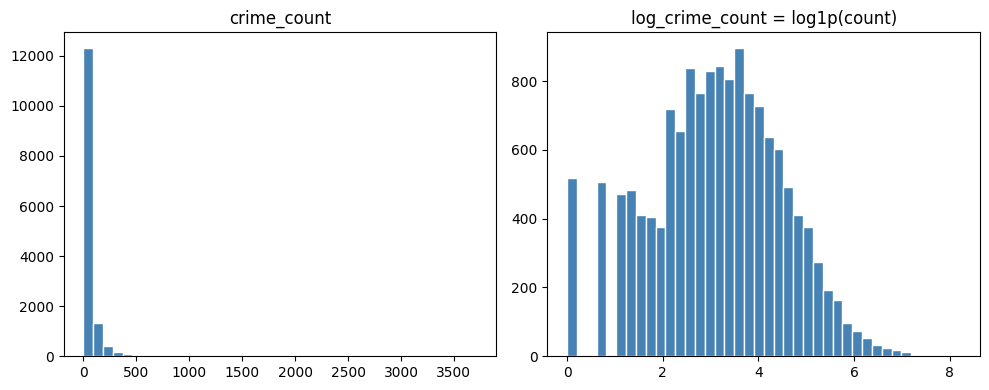

In [8]:
gdf_targets = create_targets(gdf_clean, crime_col=CFG.raw_crime_col, pop_col=CFG.raw_population_col)

n_total = len(gdf_targets)
n_pop0 = int(gdf_targets["population_zero"].sum())
print("\n=== population_zero flag ===")
print(f"Rows with population <= 0 (or missing treated as 0): {n_pop0:,} / {n_total:,} ({100*n_pop0/n_total:.2f}%)")

print("\n=== Target descriptive stats ===")
for c in ["crime_count", "log_crime_count"]:
    print("\n", c)
    print(compact_describe(gdf_targets[c]).round(4).to_string())

plot_target_histograms(gdf_targets)


## 8. Filter rows and columns

Rows with **`population_zero = True`** are **excluded** from exported model-ready datasets.


In [9]:
full_gdf_for_inspection = gdf_targets.copy()
model_gdf = gdf_targets.loc[~gdf_targets["population_zero"]].copy()
print("Rows: full =", len(gdf_targets), ", model =", len(model_gdf))

if "a_opp_ha" in model_gdf.columns:
    area_km2 = pd.to_numeric(model_gdf["a_opp_ha"], errors="coerce") / 100.0
    model_gdf["pop_density_per_km2"] = np.where(area_km2 > 0, model_gdf["population"] / area_km2, np.nan)

# Single modeling target (thesis requirement)
TARGET_COLS = ["log_crime_count"]

# Additional non-feature columns to protect from imputation/dropping
NON_FEATURE_COLS = ["crime_count", "population", "population_zero"]

PROTECT_COLS = IDENTIFIER_COLS + SPATIAL_META_COLS + TARGET_COLS + NON_FEATURE_COLS

filtered_gdf, dropped_cols = drop_high_missing_columns(model_gdf, CFG.missing_col_threshold, protect_cols=PROTECT_COLS)

print("\nDropped columns due to missingness (n=%d):" % len(dropped_cols))
print(dropped_cols)
print("\nRetained columns:", len(filtered_gdf.columns))


Rows: full = 14494 , model = 14019

Dropped columns due to missingness (n=34):
['p_stadsv', 'p_won_z_ag', 'p_won_m_ag ', 'p_won_zs', 'p_won_ev ', 'a_lp_pub', 'a_opl_bvm', 'a_opl_hvm', 'a_opl_hw', 'a_arb_wz', 'p_arb_pp', 'p_arb_wn', 'p_arb_wnv', 'p_arb_wnf', 'p_arb_zs', 'a_inkont', 'g_ink_po', 'g_ink_pi', 'p_ink_li', 'p_ink_hi', 'g_hh_sti', 'p_hh_li', 'p_hh_hi', 'p_hh_lkk', 'p_hh_osm', 'p_hh_110', 'p_hh_120', 'm_hh_ver', 'a_jz_tn', 'p_jz_tn', 'a_wmo_t', 'p_wmo_t', 'Gemeentenaam_2', 'SoortRegio_3']

Retained columns: 107


## 9. Spatial weights and spillover feature engineering

### Imputation note (important)

The median imputation below is used here for **dataset preparation and exploratory modeling only**.

**TODO (thesis-grade evaluation):** for final model comparison, imputation (and scaling, if used) should be fit **inside cross-validation pipelines** on training folds only, then applied to validation folds, to avoid optimistic bias.


In [10]:
EXCLUDE_FROM_IMPUTE = PROTECT_COLS
imputed_gdf, impute_values = median_impute_numeric(filtered_gdf, exclude_cols=EXCLUDE_FROM_IMPUTE)

print("\n=== Imputation values (median) used (top 30) ===")
print(impute_values.sort_index().head(30).round(4).to_string())

geo_ready = imputed_gdf.dropna(subset=["geometry"]).copy()
geo_ready = ensure_metric_crs(geo_ready, CFG.metric_crs)

neighbors, w_summary = build_queen_neighbors(geo_ready, key=CFG.tabular_key)
print("\n=== Queen contiguity summary ===")
print(w_summary.round(4).to_string(index=False))



=== Imputation values (median) used (top 30) ===
GeregistreerdeMisdrijven_1        23.0
ID                            119287.0
a_00_14                          105.0
a_15_24                           85.0
a_1p_hh                          100.0
a_25_44                          165.0
a_45_64                          210.0
a_65_oo                          150.0
a_bed_a                            0.0
a_bed_bf                          20.0
a_bed_gi                          20.0
a_bed_hj                          10.0
a_bed_kl                           5.0
a_bed_mn                          30.0
a_bed_oq                          20.0
a_bed_ru                          10.0
a_bedv                           105.0
a_bst_b                          305.0
a_bst_nb                          85.0
a_eur_al                          50.0
a_gbl_eu                          25.0
a_gbl_ne                          30.0
a_geb                              5.0
a_geb_eu                          20.0
a_geb_ne      


=== Queen contiguity summary ===
 n_units  avg_neighbors  min_neighbors  max_neighbors  pct_islands
   14019         5.5868              0             36       0.0713


## 9b. Spillover features (EXOGENOUS predictors only)

Spillover features are constructed **only** from a small set of **exogenous predictors**.

We intentionally **do not** include contemporaneous target-based spatial lags in exported datasets (e.g., neighbor lags of the crime target), because they are hard to defend in a cross-sectional prediction setting and can invite leakage-like interpretations.


In [11]:
available = set(geo_ready.columns)
spillover_features = [c for c in CFG.spillover_candidates if c in available]
# Change 5 to the desired number of spillover features
spillover_features = spillover_features[:5]

if len(spillover_features) < 3:
    raise ValueError(f"Need at least 3 spillover predictors; found: {spillover_features}")

print("Selected spillover predictors:", spillover_features)

spatial_gdf = add_spillover_lags(
    df=geo_ready,
    key=CFG.tabular_key,
    neighbors=neighbors,
    features=spillover_features,
    prefix="queen",
    islands_fill=np.nan,
)

TARGET_LAG_LIKE = [c for c in spatial_gdf.columns if re.search(r"lag_.*crime|crime.*lag|spillover_lag", c, flags=re.IGNORECASE)]
if TARGET_LAG_LIKE:
    print("\nFound target-lag-like columns (EXCLUDED from exports; exploratory only):")
    print(TARGET_LAG_LIKE)


Selected spillover predictors: ['pop_density_per_km2', 'ste_oad', 'p_huurw', 'g_pau_km', 'g_pau_hh']


## 10. Export model-ready datasets

Exports:
- `base_dataset` (**non-spatial**) → CSV
- `spatial_dataset` (**with exogenous spillovers**) → CSV and GeoPackage

Exported datasets **exclude** `population_zero` rows and **exclude** any target-lag-like features.


In [12]:
base_dataset = imputed_gdf.copy()
base_dataset = pd.DataFrame(base_dataset.drop(columns=["geometry"], errors="ignore"))

spatial_dataset = spatial_gdf.copy()

# Ensure exported datasets never contain contemporaneous target-based lags
if TARGET_LAG_LIKE:
    base_dataset = base_dataset.drop(columns=[c for c in TARGET_LAG_LIKE if c in base_dataset.columns], errors="ignore")
    spatial_dataset = spatial_dataset.drop(columns=[c for c in TARGET_LAG_LIKE if c in spatial_dataset.columns], errors="ignore")

# Defensive: GeoPackage supports only ONE geometry column
geom_cols = [c for c in spatial_dataset.columns if str(spatial_dataset.dtypes[c]) == "geometry"]
if len(geom_cols) > 1:
    extra = [c for c in geom_cols if c != "geometry"]
    print("Multiple geometry columns detected; converting extras to WKT:", extra)
    for c in extra:
        spatial_dataset[c] = spatial_dataset[c].to_wkt()

spatial_dataset = spatial_dataset.set_geometry("geometry")

CFG.export_base_csv.parent.mkdir(parents=True, exist_ok=True)
base_dataset.to_csv(CFG.export_base_csv, index=False)

spatial_dataset.to_file(CFG.export_spatial_gpkg, layer="spatial_dataset", driver="GPKG")
pd.DataFrame(spatial_dataset.drop(columns=["geometry"], errors="ignore")).to_csv(CFG.export_spatial_csv, index=False)

print("Exported base_dataset:", CFG.export_base_csv)
print("Exported spatial_dataset CSV:", CFG.export_spatial_csv)
print("Exported spatial_dataset GPKG:", CFG.export_spatial_gpkg)


INFO: Created 14,019 records


Exported base_dataset: datasets/model_ready_crime_nbh_2024.csv
Exported spatial_dataset CSV: datasets/spatial_dataset_crime_nbh_2024.csv
Exported spatial_dataset GPKG: datasets/spatial_dataset_crime_nbh_2024.gpkg


## 11. Pre-model audit summary


In [13]:
audit = {
    "starting_row_count": len(df_raw),
    "final_row_count_after_excluding_population_zero": len(model_gdf),
    "starting_column_count": df_raw.shape[1],
    "final_base_columns": len(base_dataset.columns),
    "final_spatial_columns": len(spatial_dataset.columns),
    "n_columns_dropped_missingness": len(dropped_cols),
    "selected_spillover_variables": spillover_features,
    "avg_neighbors": float(w_summary["avg_neighbors"].iloc[0]),
    "min_neighbors": int(w_summary["min_neighbors"].iloc[0]),
    "max_neighbors": int(w_summary["max_neighbors"].iloc[0]),
    "pct_islands": float(w_summary["pct_islands"].iloc[0]),
    "exported_files": [str(CFG.export_base_csv), str(CFG.export_spatial_csv), str(CFG.export_spatial_gpkg)],
}

print(pd.DataFrame([audit]).to_string(index=False))


 starting_row_count  final_row_count_after_excluding_population_zero  starting_column_count  final_base_columns  final_spatial_columns  n_columns_dropped_missingness                                selected_spillover_variables  avg_neighbors  min_neighbors  max_neighbors  pct_islands                                                                                                                       exported_files
              14494                                            14019                    124                 106                    117                             34 [pop_density_per_km2, ste_oad, p_huurw, g_pau_km, g_pau_hh]       5.586846              0             36     0.071332 [datasets/model_ready_crime_nbh_2024.csv, datasets/spatial_dataset_crime_nbh_2024.csv, datasets/spatial_dataset_crime_nbh_2024.gpkg]


## Why this preprocessing pipeline is thesis-ready

- **Target transformation**: crime counts and per-capita rates are typically heavy-tailed. Using `log1p` stabilizes variance and reduces the influence of extreme outliers, making models more robust and easier to compare.
- **Excluding `population_zero` rows**: rate-based targets are undefined when population is zero. Excluding these rows avoids division-by-zero artifacts and makes the modeling dataset consistent and defensible.
- **Exogenous spillover features (instead of target lag)**: spatial context is captured using neighbor summaries of **predictors** (e.g., density, deprivation, housing composition). Contemporaneous **target** lags are avoided in the main exported datasets because they are difficult to justify in cross-sectional prediction and can invite leakage-like interpretations.
- **Median imputation**: median imputation is simple, robust, and transparent for preparing a usable dataset for exploratory modeling.
- **Leakage-safe modeling still requires CV pipelines**: for final thesis-grade model comparison, imputation (and any scaling/encoding) should be fit **within each training fold** and applied to its validation fold, to prevent optimistic bias.


## Final exported datasets

- **Base (non-spatial) modeling dataset**: `datasets/model_ready_crime_nbh_2024.csv`
  - **contains**: cleaned **non-spatial** predictors + the single target column
  - **excludes**: geometry

- **Spatial modeling dataset**: `datasets/spatial_dataset_crime_nbh_2024.csv` and `datasets/spatial_dataset_crime_nbh_2024.gpkg`
  - **contains**: the same cleaned predictors + the single target column **plus** exogenous spillover features (Queen contiguity)
  - **includes**: geometry in the GPKG export

- **Single target used for modeling**: `log_crime_count = log1p(crime_count)`

- **Spillover variables included** (exogenous only; generated in section 9b):
  - `spillover_features` (printed in the pipeline output)
  - for each selected feature \(X\): `queen_lag_mean_X` and `queen_lag_sum_X`

- **No contemporaneous target lag is exported** (any target-lag-like columns are detected and removed before export).


In [14]:
import re

print("=== Exported columns: base_dataset ===")
print(sorted(base_dataset.columns.tolist()))

print("\n=== Exported columns: spatial_dataset ===")
# For the CSV export we drop geometry; for the GPKG export geometry remains
spatial_cols = [c for c in spatial_dataset.columns.tolist() if c != "geometry"]
print(sorted(spatial_cols))

def find_target_lag_like(cols):
    return [c for c in cols if re.search(r"lag_.*crime|crime.*lag|spillover_lag", c, flags=re.IGNORECASE)]

base_lag_like = find_target_lag_like(base_dataset.columns)
spatial_lag_like = find_target_lag_like(spatial_dataset.columns)

print("\n=== Target-lag-like columns remaining? ===")
print("base_dataset:", base_lag_like)
print("spatial_dataset:", spatial_lag_like)

print("\n=== Duplicate column names? ===")
print("base_dataset duplicates:", base_dataset.columns[base_dataset.columns.duplicated()].tolist())
print("spatial_dataset duplicates:", spatial_dataset.columns[spatial_dataset.columns.duplicated()].tolist())


=== Exported columns: base_dataset ===
['GeregistreerdeMisdrijven_1', 'ID', 'Perioden', 'SoortMisdrijf', 'a_00_14', 'a_15_24', 'a_1p_hh', 'a_25_44', 'a_45_64', 'a_65_oo', 'a_bed_a', 'a_bed_bf', 'a_bed_gi', 'a_bed_hj', 'a_bed_kl', 'a_bed_mn', 'a_bed_oq', 'a_bed_ru', 'a_bedv', 'a_bst_b', 'a_bst_nb', 'a_eur_al', 'a_gbl_eu', 'a_gbl_ne', 'a_geb', 'a_geb_eu', 'a_geb_ne', 'a_geb_nl', 'a_gehuwd', 'a_gesch', 'a_hh', 'a_hh_m_k', 'a_hh_z_k', 'a_inw', 'a_lan_ha', 'a_m2w', 'a_man', 'a_nb_vastg', 'a_nb_won ', 'a_neu_al', 'a_nl_all', 'a_ongeh', 'a_ons_hbo', 'a_ons_mbo', 'a_ons_po', 'a_ons_vovavo', 'a_ons_wo', 'a_opp_ha', 'a_pau', 'a_soz_ao', 'a_soz_ow', 'a_soz_wb', 'a_soz_ww', 'a_ste', 'a_vastg', 'a_verwed', 'a_vrouw', 'a_wat_ha', 'a_woning', 'bev_dich', 'centroid_x', 'centroid_y', 'crime_count', 'g_3km_sc', 'g_afs_gs', 'g_afs_hp', 'g_afs_kv', 'g_afs_sc', 'g_ele', 'g_ele_tr', 'g_gas', 'g_hhgro', 'g_pau_hh', 'g_pau_km', 'g_wozbag', 'gm_naam', 'gwb_code', 'gwb_code_10', 'gwb_code_8', 'ind_wbi', 'log_cr